In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('../artifacts/sentiment_analysis.csv')

In [4]:
data.head(5)

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


# Data Preprocessing

In [5]:
data.shape

(7920, 3)

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

### Text Preprocessing

In [10]:
import re
import string

In [11]:
data['tweet'].head(5)

0    #fingerprint #Pregnancy Test https://goo.gl/h1...
1    Finally a transparant silicon case ^^ Thanks t...
2    We love this! Would you go? #talk #makememorie...
3    I'm wired I know I'm George I was made that wa...
4    What amazing service! Apple won't even talk to...
Name: tweet, dtype: str

In [12]:
data['tweet'] = data['tweet'].apply(lambda x: ' '.join(word.lower() for word in x.split()))

In [13]:
data['tweet'].head(5)

0    #fingerprint #pregnancy test https://goo.gl/h1...
1    finally a transparant silicon case ^^ thanks t...
2    we love this! would you go? #talk #makememorie...
3    i'm wired i know i'm george i was made that wa...
4    what amazing service! apple won't even talk to...
Name: tweet, dtype: str

### Remove Links

In [14]:
data['tweet'] = data['tweet'].apply(lambda x: ' '.join(re.sub(r'http[s]?://\S+|www\.\S+', '', x, flags=re.MULTILINE) for x in x.split()))

In [15]:
data['tweet'].head(5)

0    #fingerprint #pregnancy test  #android #apps #...
1    finally a transparant silicon case ^^ thanks t...
2    we love this! would you go? #talk #makememorie...
3    i'm wired i know i'm george i was made that wa...
4    what amazing service! apple won't even talk to...
Name: tweet, dtype: str

### Remove Numbers

In [17]:
data['tweet'].tail(10)

7910    perfect match #instagood #applewatch #red #ins...
7911    i am completely in love with the new iphone em...
7912    tune in. turn on. drop out. & #gtd in one app!...
7913    ok so my galaxy crashed after one day now i ha...
7914    gain followers rt this must follow me i follow...
7915    live out loud #lol #liveoutloud #selfie #smile...
7916    we would like to wish you an amazing day! make...
7917    helping my lovely 90 year old neighbor with he...
7918    finally got my #smart #pocket #wifi stay conne...
7919    apple barcelona!!! #apple #store #bcn #barcelo...
Name: tweet, dtype: str

In [19]:
data['tweet'] = data['tweet'].str.replace(r'\d+', '', regex=True)

In [20]:
data['tweet'].tail(10)

7910    perfect match #instagood #applewatch #red #ins...
7911    i am completely in love with the new iphone em...
7912    tune in. turn on. drop out. & #gtd in one app!...
7913    ok so my galaxy crashed after one day now i ha...
7914    gain followers rt this must follow me i follow...
7915    live out loud #lol #liveoutloud #selfie #smile...
7916    we would like to wish you an amazing day! make...
7917    helping my lovely  year old neighbor with her ...
7918    finally got my #smart #pocket #wifi stay conne...
7919    apple barcelona!!! #apple #store #bcn #barcelo...
Name: tweet, dtype: str

### Remove Stopwords

In [21]:
!pip install nltk

  Using cached click-8.4.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached regex-2026.5.9-cp313-cp313-win_amd64.whl.metadata (41 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ----------------------------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import nltk
nltk.download('stopwords', download_dir='../static/model')

[nltk_data] Downloading package stopwords to ../static/model...
[nltk_data]   Unzipping corpora\stopwords.zip.
D:\Python\sentiment-analysis-project\env\Lib\site-packages\nltk\downloader.py:2395: RuntimeWarning: Security Violation [pathsec.ZipFile]: Unauthorized path D:\Python\sentiment-analysis-project\static\model\corpora\stopwords.zip
  zf = ZipFile(filename)


True

In [24]:
with open('../static/model/corpora/stopwords/english', 'r') as file:
    sw = file.read().splitlines()

In [25]:
sw

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [26]:
data['tweet'] = data['tweet'].apply(lambda x: ' '.join(x for x in x.split() if x not in sw))

In [27]:
data.head(5)

,id,label,tweet
0,1,0,#fingerprint #pregnancy test #android #apps #b...
1,2,0,finally transparant silicon case ^^ thanks unc...
2,3,0,love this! would go? #talk #makememories #unpl...
3,4,0,wired know george made way ;) #iphone #cute #d...
4,5,1,amazing service! apple even talk question unle...


### Remove Punctuations

In [28]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [29]:
def remove_punctuations(text):
    for punctuation in string.punctuation:
        text = text.replace(punctuation, '')
    return text

data['tweet'] = data['tweet'].apply(remove_punctuations)

In [30]:
data.head(5)

,id,label,tweet
0,1,0,fingerprint pregnancy test android apps beauti...
1,2,0,finally transparant silicon case thanks uncle...
2,3,0,love this would go talk makememories unplug re...
3,4,0,wired know george made way iphone cute davent...
4,5,1,amazing service apple even talk question unles...


### Stemming

In [31]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [32]:
data['tweet'] = data['tweet'].apply(lambda x: ' '.join(ps.stem(x) for x in x.split()))

In [34]:
data

,id,label,tweet
0,1,0,fingerprint pregnanc test android app beauti c...
1,2,0,final transpar silicon case thank uncl yay son...
2,3,0,love thi would go talk makememori unplug relax...
3,4,0,wire know georg made way iphon cute daventri home
4,5,1,amaz servic appl even talk question unless pay...
...,...,...,...
7915,7916,0,live loud lol liveoutloud selfi smile soni mus...
7916,7917,0,would like wish amaz day make everi minut coun...
7917,7918,0,help love year old neighbor ipad morn made rea...
7918,7919,0,final got smart pocket wifi stay connect anyti...


### Building Vocabulary

In [36]:
from collections import Counter
vocab = Counter()

In [41]:
for sentence in data['tweet']:
    vocab.update(sentence.split())

In [43]:
len(vocab)

15969

In [44]:
data.shape

(7920, 3)

If overfit more than higher features to rows

In [45]:
tokens = [key for key in vocab if vocab[key] > 10]

In [47]:
len(tokens)

1178

In [48]:
tokens

['test',
 'android',
 'app',
 'beauti',
 'cute',
 'health',
 'iger',
 'iphoneonli',
 'iphonesia',
 'iphon',
 'final',
 'case',
 'thank',
 'yay',
 'soni',
 'xperia',
 's',
 'love',
 'thi',
 'would',
 'go',
 'talk',
 'relax',
 'smartphon',
 'wifi',
 'connect',
 'know',
 'made',
 'way',
 'home',
 'amaz',
 'servic',
 'appl',
 'even',
 'question',
 'pay',
 'stupid',
 'support',
 'softwar',
 'updat',
 'fuck',
 'phone',
 'big',
 'time',
 'happi',
 'us',
 'instap',
 'instadaili',
 'xperiaz',
 'new',
 'type',
 'c',
 'charger',
 'cabl',
 'uk',
 '…',
 'amazon',
 'year',
 'newyear',
 'start',
 'technolog',
 'samsunggalaxi',
 'iphonex',
 'shop',
 'listen',
 'music',
 'likeforlik',
 'photo',
 'fun',
 'selfi',
 'water',
 'camera',
 'picoftheday',
 'sun',
 'instagood',
 'boy',
 'outdoor',
 'hey',
 'make',
 'ipod',
 'dont',
 'color',
 'inch',
 'crash',
 'everi',
 'need',
 'to',
 'realli',
 'drop',
 'ball',
 'design',
 'give',
 'anoth',
 'crazi',
 'purchas',
 'lol',
 'work',
 'hard',
 'play',
 'ipad',
 

In [50]:
def save_voc(lines, filename):
    data = '\n'.join(lines)
    file = open(filename, 'w', encoding='utf-8')
    file.write(data)
    file.close()

save_voc(tokens, '../static/model/vocabulary.txt')

### Divide Dataset to Test & Train

In [51]:
X = data['tweet']
y = data['label']

In [53]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 471.8 kB/s eta 0:00:17
   -- ------------------------------------- 0.5/8.2 MB 471.8 kB/s eta 0:00:17
   -- ------------------------------------- 0.5/8.2 MB 471.8 kB/s eta 0:00:17
   --- ------------------------------------ 0.8/8.2 MB 453.5 kB/s eta 0:00:17
   --- ------------------------------------ 0.8/8.2 MB 453.5 kB/s eta 0:00:17
   --- ------------------------------------ 0.8/8.2 MB 453.5 kB/s eta 0:00:17
   ----- ---------------------------------- 1.0/8.2 MB 460.9 kB/s eta 0:00:16
   ----- ---------------------------------- 1.0/8.2 MB 460.9 kB/s eta 0:00:16
   ----- ----------------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [71]:
X_train.shape

(6336,)

In [72]:
X_test.shape

(1584,)

### Vectorization

In [57]:
def vectorizer(ds, vocabulary):
    vectorized_list = []
    for sentence in ds:
        sentence_list = np.zeros(len(vocabulary))
        for i in range(len(vocabulary)):
            if vocabulary[i] in sentence.split():
                sentence_list[i] = 1
        vectorized_list.append(sentence_list)
    vectorized_array = np.asarray(vectorized_list, dtype=np.float32)
    return vectorized_array

In [82]:
vec_x_train = vectorizer(X_train, tokens)
vec_x_test = vectorizer(X_test, tokens)

In [83]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("vec_x_train:", vec_x_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (6336,)
y_train: (6336,)
vec_x_train: (6336, 1178)
X_test: (1584,)
y_test: (1584,)


In [84]:
for i in vec_x_train[1]:
    print(i)

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [85]:
y_train.value_counts()

label
0    4705
1    1631
Name: count, dtype: int64

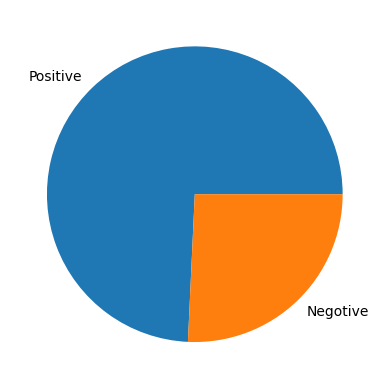

In [86]:
plt.pie(np.array([y_train.value_counts()[0], y_train.value_counts()[1]]), labels=['Positive', 'Negotive'])
plt.show()

### Handle Imbalance Dataset

In [66]:
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [87]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
vec_x_train_smote, y_train_imote = smote.fit_resample(vec_x_train, y_train)
print(vec_x_train_smote.shape, y_train_imote.shape)

(9410, 1178) (9410,)


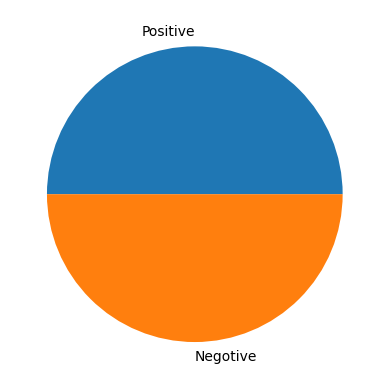

In [88]:
plt.pie(np.array([y_train_imote.value_counts()[0], y_train_imote.value_counts()[1]]), labels=['Positive', 'Negotive'])
plt.show()

In [89]:
vec_x_train_smote

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.80732703, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(9410, 1178), dtype=float32)

In [90]:
y_train_imote

0       0
1       0
2       0
3       0
4       1
       ..
9405    1
9406    1
9407    1
9408    1
9409    1
Name: label, Length: 9410, dtype: int64

In [91]:
vec_x_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1584, 1178), dtype=float32)

In [92]:
y_test

3260    0
5500    0
1421    0
3768    1
2768    0
       ..
839     0
3286    0
4266    1
3157    0
4947    0
Name: label, Length: 1584, dtype: int64

### Model Training & Evaluation

In [94]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [95]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def training_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred), 3)
    pr = round(precision_score(y_act, y_pred), 3)
    rec = round(recall_score(y_act, y_pred), 3)
    f1 = round(f1_score(y_act, y_pred), 3)

    print(
        f"Training Scores:\n"
        f"\tAccuracy  = {acc}\n"
        f"\tPrecision = {pr}\n"
        f"\tRecall    = {rec}\n"
        f"\tF1-Score  = {f1}"
    )


def validation_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred), 3)
    pr = round(precision_score(y_act, y_pred), 3)
    rec = round(recall_score(y_act, y_pred), 3)
    f1 = round(f1_score(y_act, y_pred), 3)

    print(
        f"Testing Scores:\n"
        f"\tAccuracy  = {acc}\n"
        f"\tPrecision = {pr}\n"
        f"\tRecall    = {rec}\n"
        f"\tF1-Score  = {f1}"
    )

### Logistic Regression

In [105]:
lr = LogisticRegression()
lr.fit(vec_x_train_smote, y_train_imote)

y_train_pred = lr.predict(vec_x_train_smote)

training_scores(y_train_imote, y_train_pred)

y_test_pred = lr.predict(vec_x_test)

validation_scores(y_test, y_test_pred)

Training Scores:
	Accuracy  = 0.94
	Precision = 0.917
	Recall    = 0.967
	F1-Score  = 0.941
Testing Scores:
	Accuracy  = 0.874
	Precision = 0.705
	Recall    = 0.853
	F1-Score  = 0.772


### Naive Bayes

In [106]:
mnb = MultinomialNB()
mnb.fit(vec_x_train_smote, y_train_imote)

y_train_pred = mnb.predict(vec_x_train_smote)

training_scores(y_train_imote, y_train_pred)

y_test_pred = mnb.predict(vec_x_test)

validation_scores(y_test, y_test_pred)

Training Scores:
	Accuracy  = 0.909
	Precision = 0.872
	Recall    = 0.958
	F1-Score  = 0.913
Testing Scores:
	Accuracy  = 0.869
	Precision = 0.672
	Recall    = 0.927
	F1-Score  = 0.779


### Decision Tree Classifier

In [108]:
dtc = DecisionTreeClassifier()
dtc.fit(vec_x_train_smote, y_train_imote)

y_train_pred = dtc.predict(vec_x_train_smote)

training_scores(y_train_imote, y_train_pred)

y_test_pred = dtc.predict(vec_x_test)

validation_scores(y_test, y_test_pred)

Training Scores:
	Accuracy  = 1.0
	Precision = 1.0
	Recall    = 0.999
	F1-Score  = 1.0
Testing Scores:
	Accuracy  = 0.839
	Precision = 0.678
	Recall    = 0.676
	F1-Score  = 0.677


### Random Forest Classifier

In [110]:
rfc = RandomForestClassifier()
rfc.fit(vec_x_train_smote, y_train_imote)

y_train_pred = rfc.predict(vec_x_train_smote)

training_scores(y_train_imote, y_train_pred)

y_test_pred = rfc.predict(vec_x_test)

validation_scores(y_test, y_test_pred)

Training Scores:
	Accuracy  = 1.0
	Precision = 0.999
	Recall    = 1.0
	F1-Score  = 1.0
Testing Scores:
	Accuracy  = 0.877
	Precision = 0.754
	Recall    = 0.752
	F1-Score  = 0.753


### Support Vector Machine

In [111]:
svm = SVC()
svm.fit(vec_x_train_smote, y_train_imote)

y_train_pred = svm.predict(vec_x_train_smote)

training_scores(y_train_imote, y_train_pred)

y_test_pred = svm.predict(vec_x_test)

validation_scores(y_test, y_test_pred)

Training Scores:
	Accuracy  = 0.978
	Precision = 0.961
	Recall    = 0.996
	F1-Score  = 0.978
Testing Scores:
	Accuracy  = 0.88
	Precision = 0.735
	Recall    = 0.813
	F1-Score  = 0.772


In [112]:
import pickle

with open('../static/model/model.pickle', 'wb') as file:
    pickle.dump(lr, file)